In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Grokking Machine Learning/03- Python Machine Learning/W18/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# EDA

In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
# Float Format
pd.options.display.float_format = '{:.1f}'.format

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.0,200.0,200.0,200.0
mean,100.5,38.9,60.6,50.2
std,57.9,14.0,26.3,25.8
min,1.0,18.0,15.0,1.0
25%,50.8,28.8,41.5,34.8
50%,100.5,36.0,61.5,50.0
75%,150.2,49.0,78.0,73.0
max,200.0,70.0,137.0,99.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## CustomerID

In [7]:
df.drop('CustomerID', axis =1, inplace=True)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [8]:
df.columns = ['gender', 'age', 'income', 'score']

In [9]:
df.head()

,gender,age,income,score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## Gender

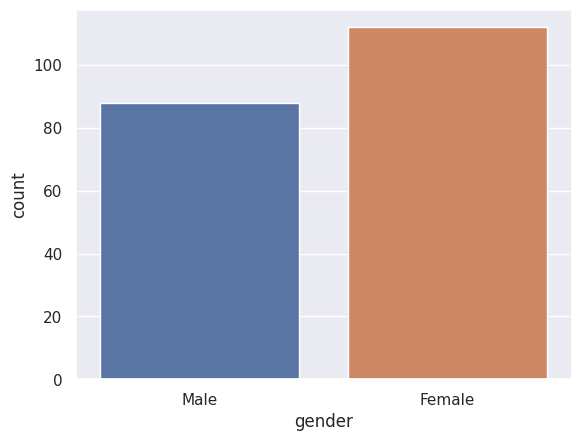

In [10]:
sns.countplot(x= df.gender);

In [11]:
df.groupby('gender').mean()

,age,income,score
gender,,,
Female,38.1,59.2,51.5
Male,39.8,62.2,48.5


## Age

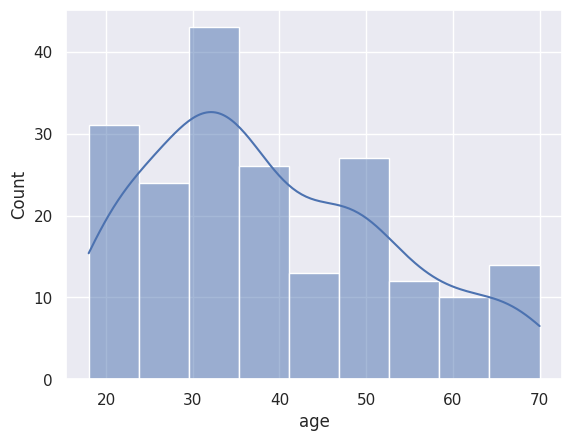

In [12]:
sns.histplot(df.age, kde=True);

## Annual Income (k$)

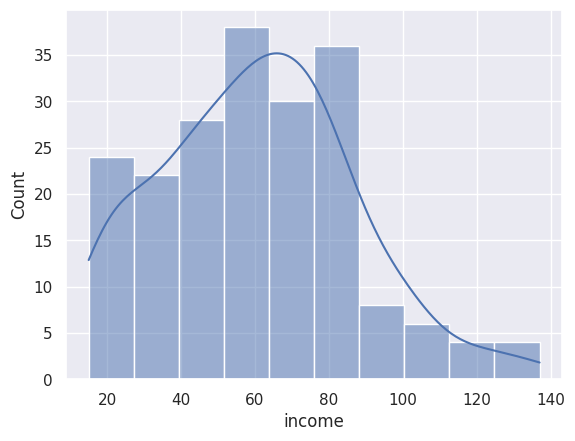

In [13]:
sns.histplot(df.income, kde=True);

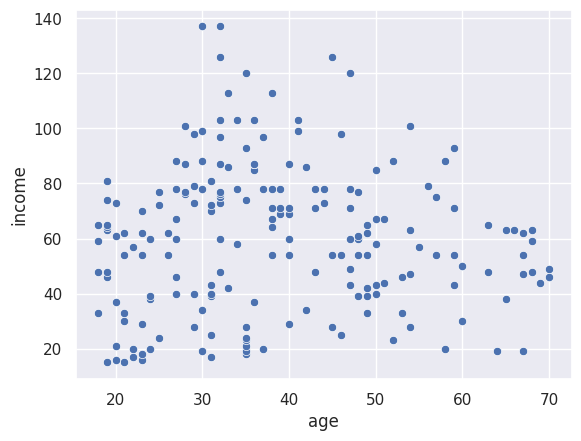

In [14]:
sns.scatterplot(df, x='age', y='income');

## Spending Score (1-100)

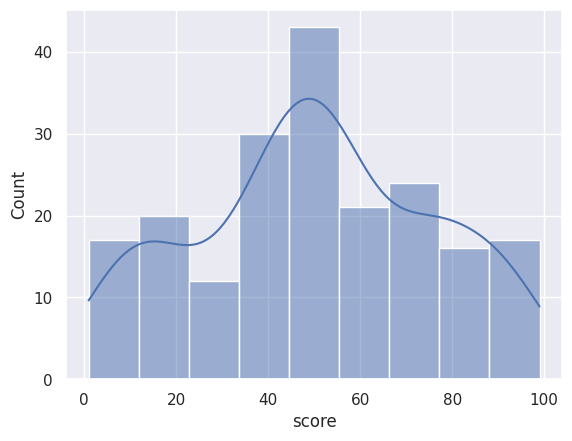

In [15]:
sns.histplot(df.score, kde=True);

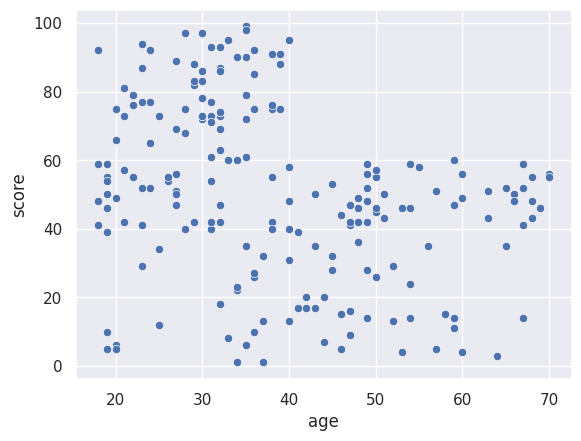

In [16]:
sns.scatterplot(df, x='age', y='score');

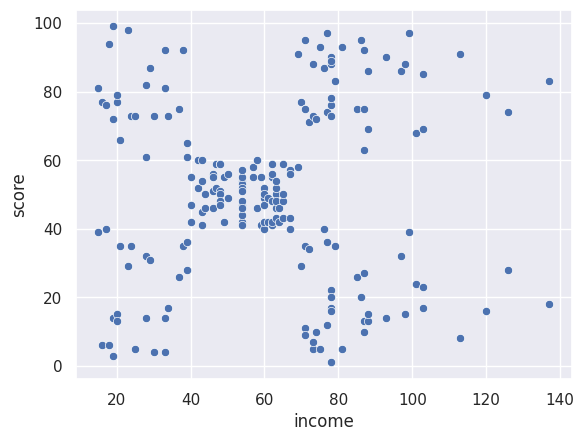

In [17]:
sns.scatterplot(df, x='income', y='score');

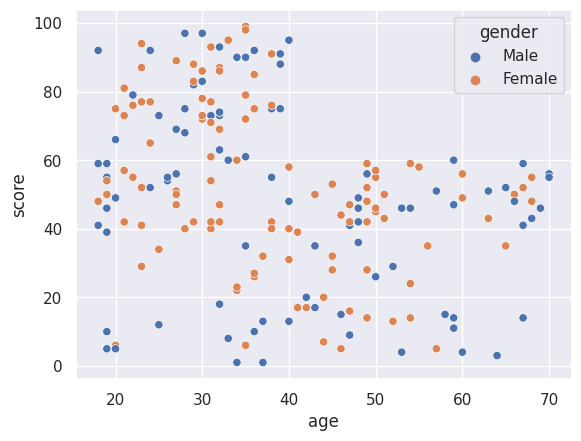

In [18]:
sns.scatterplot(df, x='age', y='score', hue='gender');

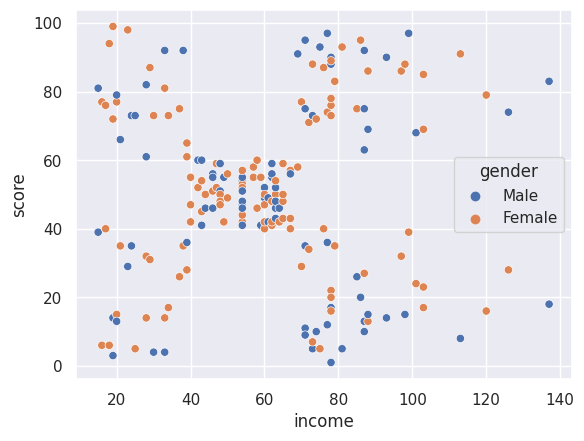

In [19]:
sns.scatterplot(df, x='income', y='score', hue='gender');

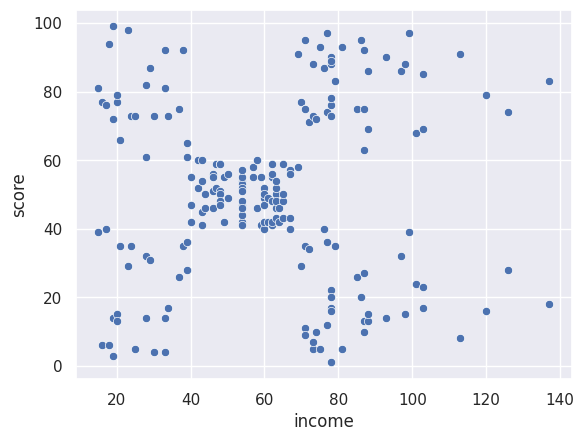

In [20]:
sns.scatterplot(df, x='income', y='score');

This is the most informative visualization till now, as we can observe about 5 clusters:
1. Low Score, Low Income
2. Low Score, High Income
3. Mid Score, Mid Income
4. High Score, Low Income
5. High Score, High Income

**Considering only those two features, we can build our first**

In [21]:
X= df[['income', 'score']]

# Scaling

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Clustering using K-means

In [23]:
from sklearn.cluster import KMeans

km5 = KMeans(n_clusters= 5, init='k-means++', n_init='auto', random_state=0)
y_pred = km5.fit_predict(X)

In [24]:
(y_pred == km5.labels_).all()

True

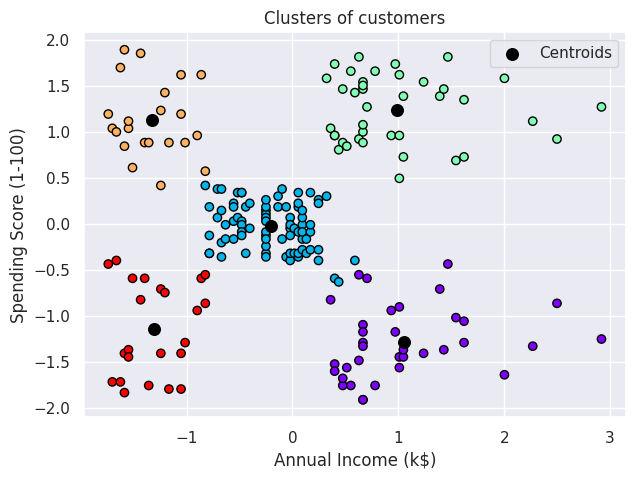

In [37]:
#Visualizing all the clusters
plt.figure(figsize=(7,5))
color_dict = {0:'yellow', 1: 'red', 2: 'blue', 3: 'green', 4:'white'}
plt.scatter(x = X[:,0],y = X[:,1],c = y_pred,cmap = 'rainbow',edgecolor = 'black')
plt.scatter(km5.cluster_centers_[:, 0], km5.cluster_centers_[:, 1], s = 70, c = 'black', label = 'Centroids')


plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [30]:
X_new = [[30, 88]]
X_new = scaler.transform(X_new)
km5.predict(X_new)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([3], dtype=int32)

In [50]:
color_dict = {0:'yellow', 1: 'red', 2: 'blue', 3: 'green', 4:'white'}
pd.DataFrame(y_pred)[0].map(color_dict)

0       white
1       green
2       white
3       green
4       white
        ...  
195      blue
196    yellow
197      blue
198    yellow
199      blue
Name: 0, Length: 200, dtype: object

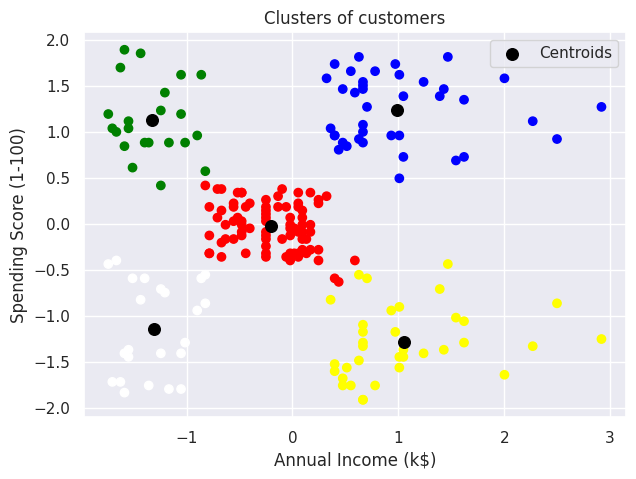

In [51]:
#Visualizing all the clusters
plt.figure(figsize=(7,5))
plt.scatter(x = X[:,0],y = X[:,1],c = pd.DataFrame(y_pred)[0].map(color_dict))
plt.scatter(km5.cluster_centers_[:, 0], km5.cluster_centers_[:, 1], s = 70, c = 'black', label = 'Centroids')


plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

**We can try different number of clusters to find the optimum number of clusters using Elbow Method**

## Elbow Method

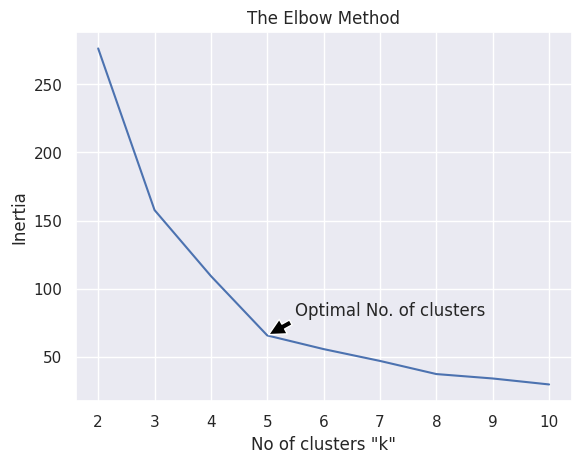

In [26]:
X= df[['income', 'score']]
X = scaler.fit_transform(X)

# Within-cluster Sum of Squares (Inertia)
inertia=[]
k_range= range(2,11)

for i in k_range:
    kmeans_i = KMeans(n_clusters= i, init='k-means++', n_init='auto', random_state=0)
    kmeans_i.fit(X)
    inertia.append(kmeans_i.inertia_)

# Visualizing the ELBOW method to get the optimal value of K
sns.lineplot(x=k_range, y=inertia)
plt.title('The Elbow Method')
plt.xlabel('No of clusters "k"')
plt.ylabel('Inertia')

# Annotate arrow
plt.annotate('Optimal No. of clusters', xy=(5, inertia[3]), xytext=(5.5, 80), arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

>  Elbow Method shows that the optimal number of clusters is 5

In [27]:
km5.inertia_

65.56840815571681

In [28]:
km5.score(X)   # Greater is Better

-65.56840815571681

# Silhouette Score for K-Means Clusters

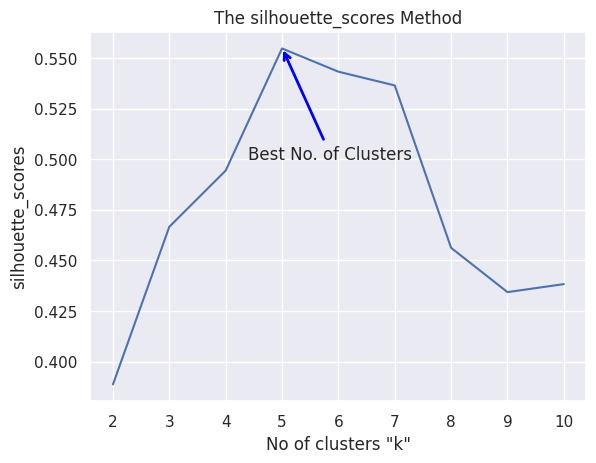

In [29]:
from sklearn.metrics import silhouette_score
silhouette_scores=[]
k_range= range(2,11)

for i in k_range:
    kmeans = KMeans(n_clusters= i, init='k-means++', n_init='auto', random_state=0)
    kmeans.fit(X)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_, metric='euclidean'))

# Visualizing the silhouette_scores method to get the optimal value of K
sns.lineplot(x=k_range, y=silhouette_scores)
plt.title('The silhouette_scores Method')
plt.xlabel('No of clusters "k"')
plt.ylabel('silhouette_scores')

# Annotate arrow
plt.annotate('Best No. of Clusters', xy=(5, 0.555), xytext=(4.4, 0.5), xycoords='data',
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='blue', lw=2))


plt.show()
